# Pertemuan 7 - Pengantar Machine Learning: Regresi Linear

**Nama:** Suryani Tangdiaga  
**NIM:** 250401020097  
**Kelas:** IF405

Materi:
- Regresi Linear
- Train Test Split
- StandardScaler
- Evaluasi Model
- Visualisasi Prediksi

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Langkah 1 - Generate Dataset Sintetis dan EDA

In [2]:
np.random.seed(42)

n = 300

pengalaman = np.random.uniform(0,20,n)

edu = np.random.choice(
    [0,1,2],
    n
)

kota = np.random.choice(
    ['Jakarta','Surabaya','Bandung'],
    n
)

gaji = (
    3.0
    + 2.2 * pengalaman
    + 1.5 * edu
    + np.where(kota=='Jakarta',4.0,0)
    + np.random.normal(0,2,n)
)

df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu': edu,
    'kota': kota,
    'gaji': gaji
})

df.head()

,pengalaman,edu,kota,gaji
0,7.490802,0,Jakarta,21.953247
1,19.014286,1,Jakarta,46.721665
2,14.639879,2,Surabaya,34.952649
3,11.973170,2,Bandung,32.437143
4,3.120373,2,Jakarta,17.384265


In [3]:
print("Shape:")
print(df.shape)

print("\nStatistik:")
print(df.describe().round(2))

Shape:
(300, 4)

Statistik:
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


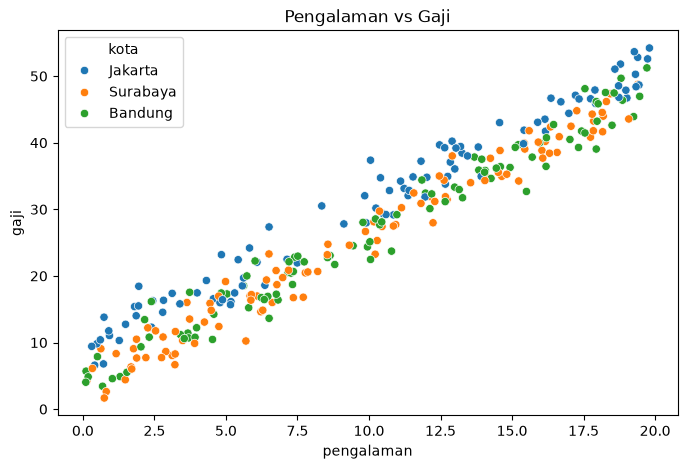

In [4]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='pengalaman',
    y='gaji',
    hue='kota'
)

plt.title('Pengalaman vs Gaji')
plt.show()

## Langkah 2 - Preprocessing

In [6]:
df = pd.get_dummies(
    df,
    columns=['kota'],
    drop_first=True,
    dtype=int
)

df.head()

,pengalaman,edu,gaji,kota_Jakarta,kota_Surabaya
0,7.490802,0,21.953247,1,0
1,19.014286,1,46.721665,1,0
2,14.639879,2,34.952649,0,1
3,11.973170,2,32.437143,0,0
4,3.120373,2,17.384265,1,0


In [7]:
X = df.drop('gaji', axis=1)
y = df['gaji']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

Train : (240, 4)
Test  : (60, 4)


In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Langkah 3 - Melatih Model Regresi Linear

In [10]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
print("Intercept:")
print(model.intercept_)

coef_df = pd.DataFrame({
    'Koefisien': model.coef_
})

coef_df

Intercept:
27.514124756898322


,Koefisien
0,13.042241
1,1.187879
2,1.837226
3,-0.291561


## Langkah 4 - Evaluasi Model

In [12]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE :", round(mae,3))
print("RMSE:", round(rmse,3))
print("R²  :", round(r2,3))

MAE : 1.649
RMSE: 2.123
R²  : 0.974


### Interpretasi

- MAE menunjukkan rata-rata kesalahan prediksi model.
- RMSE menunjukkan besar error dengan penalti lebih tinggi terhadap kesalahan besar.
- Nilai R² mendekati 1 menandakan model mampu menjelaskan variasi data dengan baik.

## Langkah 5 - Visualisasi Prediksi

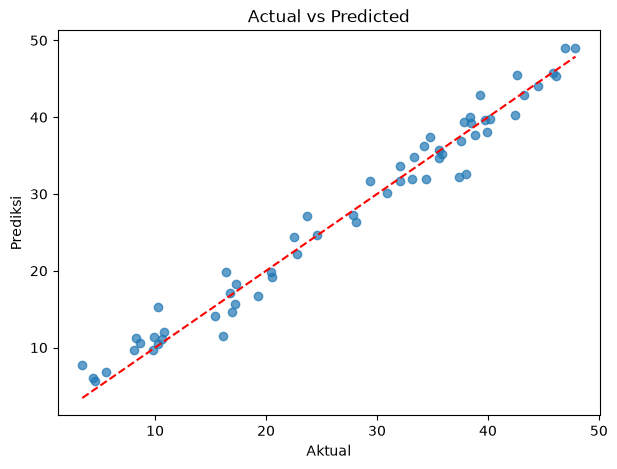

In [14]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Aktual")
plt.ylabel("Prediksi")
plt.title("Actual vs Predicted")

plt.show()

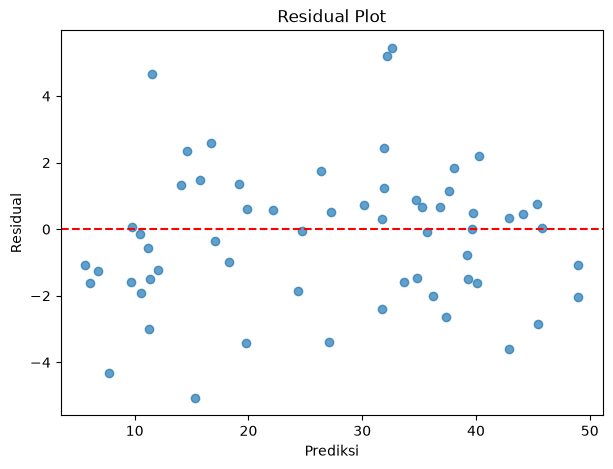

In [15]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Prediksi")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

### What?
Grafik menunjukkan hubungan antara nilai aktual dan hasil prediksi model regresi linear.

### So What?
Semakin dekat titik terhadap garis diagonal, semakin baik kemampuan model dalam melakukan prediksi.

### Now What?
Model dapat ditingkatkan dengan menambahkan fitur lain seperti usia, jabatan, sertifikasi, atau pengalaman kerja yang lebih rinci.

# Kesimpulan

1. Model Regresi Linear berhasil dibuat menggunakan Scikit-Learn.
2. Dataset berhasil diproses melalui encoding, split data, dan scaling.
3. Model mampu memprediksi gaji berdasarkan pengalaman, pendidikan, dan lokasi.
4. Nilai MAE, RMSE, dan R² digunakan untuk mengevaluasi performa model.
5. Visualisasi Actual vs Predicted dan Residual Plot membantu memahami kualitas prediksi model.